# Predicting Student Academic Performance Using Multivariate Linear Regression

## Problem Statement

Maintaining student engagement while improving academic performance is a significant challenge in modern education. Students' learning habits, attendance, motivation, and overall well-being all influence their academic success. Understanding how these factors contribute to examination performance enables educators to provide timely interventions without reducing the enjoyment of learning.

This project develops a multivariate linear regression model that predicts students' exam scores using learning behavior and lifestyle variables. Multiple regression algorithms are evaluated to determine the best-performing model, which will later be deployed as a FastAPI service and integrated into a Flutter application.

## Project Objectives

The objectives of this project are:

- Explore and understand the student performance dataset.
- Perform feature engineering and data preprocessing.
- Convert categorical variables into numerical representations.
- Standardize numerical features before training.
- Compare multiple linear regression algorithms.
- Optimize a regression model using stochastic gradient descent.
- Evaluate model performance using multiple regression metrics.
- Save the best-performing model for deployment through FastAPI.

## Importing Required Libraries

The following libraries are imported to perform data manipulation, visualization, preprocessing, model training, evaluation, and model persistence.

In [65]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import kagglehub
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    SGDRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

## Downloading the Dataset

The dataset is downloaded directly from Kaggle using KaggleHub. This approach ensures the notebook is reproducible and eliminates the need to manually download the dataset.

In [66]:
dataset_path = kagglehub.dataset_download(
    "aryan208/student-habits-and-academic-performance-dataset"
)

dataset_path

'C:\\Users\\a\\.cache\\kagglehub\\datasets\\aryan208\\student-habits-and-academic-performance-dataset\\versions\\1'

## Locating the Dataset File

The downloaded directory may contain multiple files. The following code identifies all CSV files available in the downloaded dataset.

In [67]:
csv_files = list(Path(dataset_path).rglob("*.csv"))

csv_files

[WindowsPath('C:/Users/a/.cache/kagglehub/datasets/aryan208/student-habits-and-academic-performance-dataset/versions/1/enhanced_student_habits_performance_dataset/enhanced_student_habits_performance_dataset.csv')]

## Loading the Dataset

The first CSV file in the downloaded dataset is loaded into a Pandas DataFrame.

In [68]:
df = pd.read_csv(csv_files[0])

df.head()

,student_id,age,gender,major,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,previous_gpa,semester,stress_level,dropout_risk,social_activity,screen_time,study_environment,access_to_tutoring,family_income_range,parental_support_level,motivation_level,exam_anxiety_score,learning_style,time_management_score,exam_score
0,100000,26,Male,Computer Science,7.645367,3.0,0.1,Yes,70.3,6.2,Poor,3,Some College,High,6.0,Yes,4.00,5,5.8,No,0,10.9,Co-Learning Group,Yes,High,9,7,8,Reading,3.0,100
1,100001,28,Male,Arts,5.700000,0.5,0.4,No,88.4,7.2,Good,4,PhD,Low,6.8,No,4.00,7,5.8,No,5,8.3,Co-Learning Group,Yes,Low,7,2,10,Reading,6.0,99
2,100002,17,Male,Arts,2.400000,4.2,0.7,No,82.1,9.2,Good,4,High School,Low,5.7,Yes,3.79,4,8.0,No,5,8.0,Library,Yes,High,3,9,6,Kinesthetic,7.6,98
3,100003,27,Other,Psychology,3.400000,4.6,2.3,Yes,79.3,4.2,Fair,3,Master,Medium,8.5,Yes,4.00,6,4.6,No,3,11.7,Co-Learning Group,Yes,Low,5,3,10,Reading,3.2,100
4,100004,25,Female,Business,4.700000,0.8,2.7,Yes,62.9,6.5,Good,6,PhD,Low,9.2,No,4.00,4,5.7,No,2,9.4,Quiet Room,Yes,Medium,9,1,10,Reading,7.1,98


## Dataset Overview

Before building a regression model, it is important to understand the dataset's dimensions, feature types, descriptive statistics, missing values, and duplicate records.

In [69]:
df.shape

(80000, 31)

In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     80000 non-null  int64  
 1   age                            80000 non-null  int64  
 2   gender                         80000 non-null  str    
 3   major                          80000 non-null  str    
 4   study_hours_per_day            80000 non-null  float64
 5   social_media_hours             80000 non-null  float64
 6   netflix_hours                  80000 non-null  float64
 7   part_time_job                  80000 non-null  str    
 8   attendance_percentage          80000 non-null  float64
 9   sleep_hours                    80000 non-null  float64
 10  diet_quality                   80000 non-null  str    
 11  exercise_frequency             80000 non-null  int64  
 12  parental_education_level       80000 non-null  str    
 1

In [71]:
df.describe(include="all")

,student_id,age,gender,major,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,previous_gpa,semester,stress_level,dropout_risk,social_activity,screen_time,study_environment,access_to_tutoring,family_income_range,parental_support_level,motivation_level,exam_anxiety_score,learning_style,time_management_score,exam_score
count,80000.000000,80000.000000,80000,80000,80000.000000,80000.000000,80000.000000,80000,80000.000000,80000.000000,80000,80000.000000,80000,80000,80000.000000,80000,80000.000000,80000.000000,80000.000000,80000,80000.000000,80000.000000,80000,80000,80000,80000.000000,80000.000000,80000.000000,80000,80000.000000,80000.000000
unique,NaN,NaN,3,6,NaN,NaN,NaN,2,NaN,NaN,3,NaN,5,3,NaN,2,NaN,NaN,NaN,2,NaN,NaN,5,2,3,NaN,NaN,NaN,4,NaN,NaN
top,NaN,NaN,Female,Arts,NaN,NaN,NaN,No,NaN,NaN,Good,NaN,Some College,High,NaN,No,NaN,NaN,NaN,No,NaN,NaN,Dorm,No,Low,NaN,NaN,NaN,Kinesthetic,NaN,NaN
freq,NaN,NaN,26705,13505,NaN,NaN,NaN,40195,NaN,NaN,39935,NaN,16115,26749,NaN,40058,NaN,NaN,NaN,78418,NaN,NaN,16119,40039,26720,NaN,NaN,NaN,20143,NaN,NaN
mean,139999.500000,22.004288,NaN,NaN,4.174388,2.501366,1.997754,NaN,69.967884,7.017418,NaN,3.516587,NaN,NaN,6.804108,NaN,3.602448,4.497338,5.012478,NaN,2.500225,9.673029,NaN,NaN,NaN,5.479438,5.488525,8.508475,NaN,5.499132,89.141350
std,23094.155105,3.745570,NaN,NaN,2.004135,1.445441,1.155992,NaN,17.333015,1.467377,NaN,2.291575,NaN,NaN,1.921579,NaN,0.462876,2.295312,1.953174,NaN,1.704292,2.780869,NaN,NaN,NaN,2.873327,2.867782,1.796411,NaN,2.603534,11.591497
min,100000.000000,16.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,40.000000,4.000000,NaN,0.000000,NaN,NaN,1.000000,NaN,1.640000,1.000000,1.000000,NaN,0.000000,0.300000,NaN,NaN,NaN,1.000000,1.000000,5.000000,NaN,1.000000,36.000000
25%,119999.750000,19.000000,NaN,NaN,2.800000,1.200000,1.000000,NaN,55.000000,6.000000,NaN,2.000000,NaN,NaN,5.500000,NaN,3.270000,2.000000,3.600000,NaN,1.000000,7.800000,NaN,NaN,NaN,3.000000,3.000000,7.000000,NaN,3.200000,82.000000
50%,139999.500000,22.000000,NaN,NaN,4.125624,2.500000,2.000000,NaN,69.900000,7.000000,NaN,4.000000,NaN,NaN,6.900000,NaN,3.790000,5.000000,5.000000,NaN,2.000000,9.700000,NaN,NaN,NaN,5.000000,5.000000,10.000000,NaN,5.500000,93.000000
75%,159999.250000,25.000000,NaN,NaN,5.500000,3.800000,3.000000,NaN,84.900000,8.000000,NaN,6.000000,NaN,NaN,8.200000,NaN,4.000000,7.000000,6.400000,NaN,4.000000,11.600000,NaN,NaN,NaN,8.000000,8.000000,10.000000,NaN,7.800000,100.000000


In [72]:
df.isnull().sum()

student_id                       0
age                              0
gender                           0
major                            0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
previous_gpa                     0
semester                         0
stress_level                     0
dropout_risk                     0
social_activity                  0
screen_time                      0
study_environment                0
access_to_tutoring               0
family_income_range              0
parental_support_level           0
motivation_level                 0
exam_anxiety_score               0
learning_style      

In [73]:
df.duplicated().sum()

np.int64(0)

### Interpretation

The initial exploration provides an overview of the dataset's structure and quality. Examining data types, summary statistics, missing values, and duplicate records helps identify the preprocessing steps required before training the regression models. Cleaning and preparing the dataset ensures that the resulting model is trained on reliable and consistent data.

# Exploratory Data Analysis (EDA)

Exploratory data analysis is performed to understand relationships between student habits, learning environments, and academic performance.

The analysis focuses on identifying:
- Distribution of exam scores
- Relationships between numerical features and exam performance
- Potential influential factors
- Data characteristics that will guide feature engineering decisions

## Distribution of Exam Scores

Understanding the distribution of exam scores helps determine whether the target variable is balanced or contains unusual patterns.

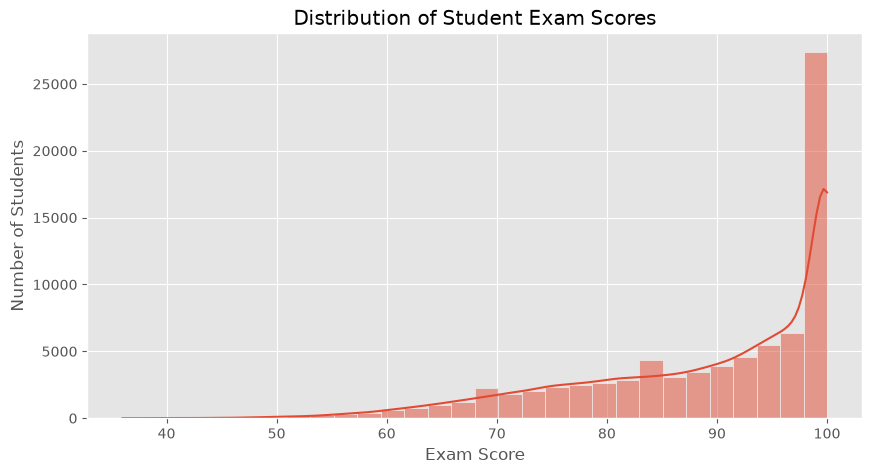

In [74]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["exam_score"],
    bins=30,
    kde=True
)

plt.title("Distribution of Student Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")

plt.show()

### Interpretation

The distribution shows how student performance is spread across the dataset. A relatively balanced distribution indicates that the model will have enough examples across different performance levels. Any extreme values will be investigated before training the regression models.

## Correlation Analysis

Correlation analysis is used to identify numerical variables that have stronger relationships with exam performance.

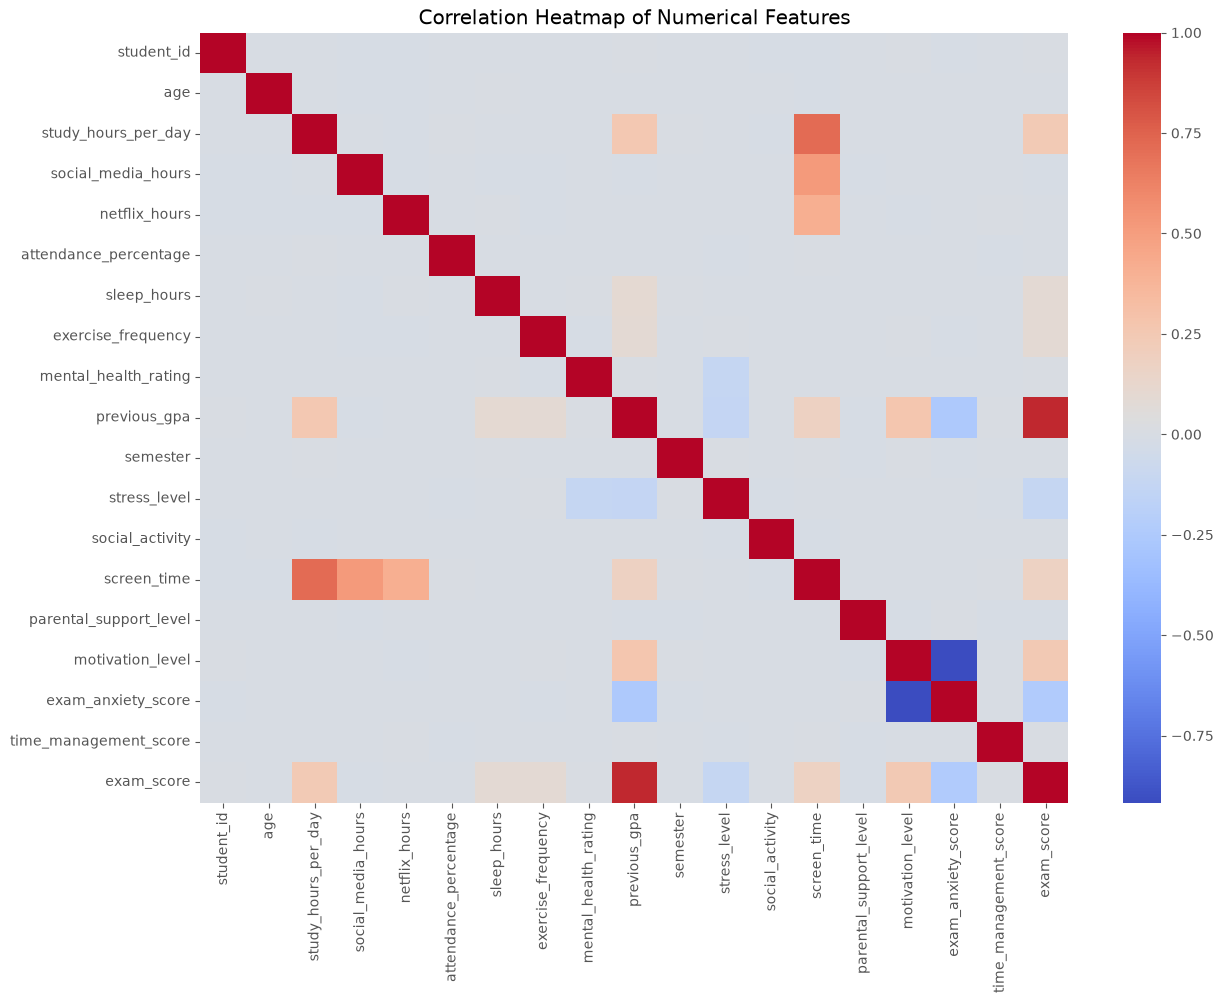

In [75]:
numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
)

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_columns.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

In [76]:
exam_correlation = (
    numeric_columns
    .corr()["exam_score"]
    .sort_values(ascending=False)
)

exam_correlation

exam_score                1.000000
previous_gpa              0.932940
motivation_level          0.250287
study_hours_per_day       0.241460
screen_time               0.169788
sleep_hours               0.090820
exercise_frequency        0.086983
mental_health_rating      0.010556
student_id                0.007557
time_management_score     0.005940
attendance_percentage     0.002876
semester                  0.000541
age                       0.000487
netflix_hours            -0.001271
social_activity          -0.002795
parental_support_level   -0.006333
social_media_hours       -0.006351
stress_level             -0.118550
exam_anxiety_score       -0.235909
Name: exam_score, dtype: float64

### Interpretation

The correlation analysis helps identify features that may contribute significantly to predicting exam scores.

Features with stronger positive correlations, such as previous GPA, study hours, attendance percentage, and time management score, are expected to provide useful predictive information.

Features with weak correlations may contribute less to the model but will be considered based on their educational relevance.

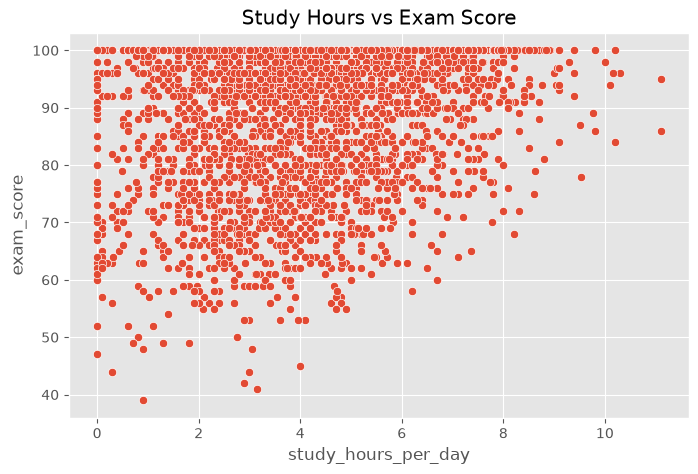

In [77]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df.sample(3000),
    x="study_hours_per_day",
    y="exam_score"
)

plt.title("Study Hours vs Exam Score")

plt.show()

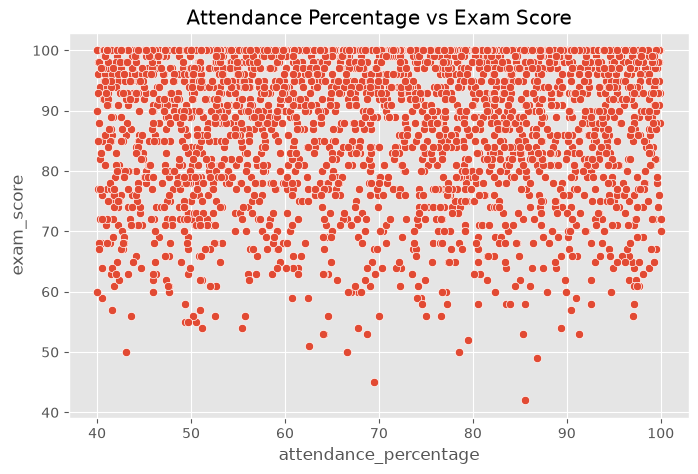

In [78]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df.sample(3000),
    x="attendance_percentage",
    y="exam_score"
)

plt.title("Attendance Percentage vs Exam Score")

plt.show()

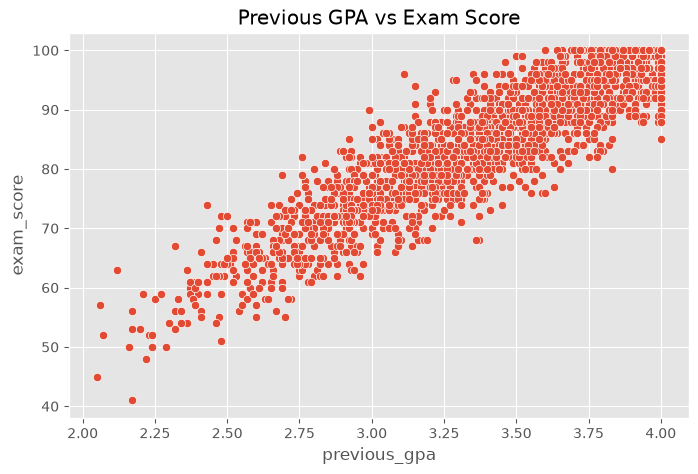

In [79]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df.sample(3000),
    x="previous_gpa",
    y="exam_score"
)

plt.title("Previous GPA vs Exam Score")

plt.show()

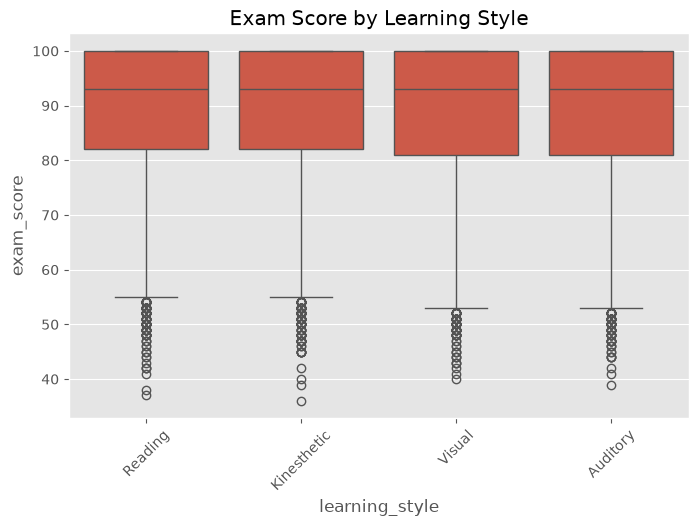

In [80]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="learning_style",
    y="exam_score"
)

plt.xticks(rotation=45)

plt.title("Exam Score by Learning Style")

plt.show()

### Interpretation

Categorical variables such as learning style, study environment, and access to tutoring may influence student performance. These features cannot directly be used by regression algorithms and will require numerical encoding during preprocessing.

# Feature Engineering

Feature engineering prepares the dataset for machine learning by selecting relevant variables, removing unnecessary information, and transforming data into a format suitable for regression algorithms.

The goal is to preserve meaningful educational factors while removing features that could negatively affect model performance or introduce data leakage.

In [81]:
df.duplicated().sum()

np.int64(0)

In [82]:
df = df.drop_duplicates()

df.shape

(80000, 31)

### Interpretation

Duplicate records are removed because repeated observations can cause the model to learn patterns from duplicated data rather than learning general relationships between learning habits and academic performance.

## Removing Irrelevant Features

Some columns do not provide meaningful information for predicting academic performance.

- `student_id` is only an identifier and does not represent a learning factor.
- `dropout_risk` is removed because it may introduce data leakage. It represents a prediction outcome rather than a direct student characteristic.

In [83]:
columns_to_drop = [
    "student_id",
    "dropout_risk"
]

df = df.drop(columns=columns_to_drop)

df.head()

,age,gender,major,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,previous_gpa,semester,stress_level,social_activity,screen_time,study_environment,access_to_tutoring,family_income_range,parental_support_level,motivation_level,exam_anxiety_score,learning_style,time_management_score,exam_score
0,26,Male,Computer Science,7.645367,3.0,0.1,Yes,70.3,6.2,Poor,3,Some College,High,6.0,Yes,4.00,5,5.8,0,10.9,Co-Learning Group,Yes,High,9,7,8,Reading,3.0,100
1,28,Male,Arts,5.700000,0.5,0.4,No,88.4,7.2,Good,4,PhD,Low,6.8,No,4.00,7,5.8,5,8.3,Co-Learning Group,Yes,Low,7,2,10,Reading,6.0,99
2,17,Male,Arts,2.400000,4.2,0.7,No,82.1,9.2,Good,4,High School,Low,5.7,Yes,3.79,4,8.0,5,8.0,Library,Yes,High,3,9,6,Kinesthetic,7.6,98
3,27,Other,Psychology,3.400000,4.6,2.3,Yes,79.3,4.2,Fair,3,Master,Medium,8.5,Yes,4.00,6,4.6,3,11.7,Co-Learning Group,Yes,Low,5,3,10,Reading,3.2,100
4,25,Female,Business,4.700000,0.8,2.7,Yes,62.9,6.5,Good,6,PhD,Low,9.2,No,4.00,4,5.7,2,9.4,Quiet Room,Yes,Medium,9,1,10,Reading,7.1,98


## Separating Features and Target Variable

The target variable for this regression problem is `exam_score`.

The remaining columns are used as input features to predict student performance.

In [84]:
X = df.drop(
    columns=["exam_score"]
)

y = df["exam_score"]

In [85]:
X.shape, y.shape

((80000, 28), (80000,))

## Identifying Numerical and Categorical Features

Regression algorithms require numerical input values. Therefore, categorical variables must be identified and converted into numerical representations.

In [86]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns

numeric_features = X.select_dtypes(
    exclude=["object"]
).columns


categorical_features, numeric_features

(Index(['gender', 'major', 'part_time_job', 'diet_quality',
        'parental_education_level', 'internet_quality',
        'extracurricular_participation', 'study_environment',
        'access_to_tutoring', 'family_income_range', 'learning_style'],
       dtype='str'),
 Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
        'attendance_percentage', 'sleep_hours', 'exercise_frequency',
        'mental_health_rating', 'previous_gpa', 'semester', 'stress_level',
        'social_activity', 'screen_time', 'parental_support_level',
        'motivation_level', 'exam_anxiety_score', 'time_management_score'],
       dtype='str'))

## Encoding Categorical Features

Categorical variables are transformed using One-Hot Encoding. This creates binary columns for each category without introducing artificial numerical relationships.

In [87]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [88]:
X_encoded = preprocessor.fit_transform(X)

X_encoded.shape

(80000, 44)

## Feature Standardization

Standardization scales numerical variables so that features have similar ranges.

This is especially important for gradient descent because large-scale features can dominate the optimization process and slow convergence.

In [89]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_encoded
)

X_scaled.shape

(80000, 44)

## Splitting the Dataset

The dataset is divided into training and testing sets.

- 80% of the data is used for training.
- 20% is used for evaluating how well the model performs on unseen students.

In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape

((64000, 44), (16000, 44))

# Training Regression Models

Three regression algorithms are implemented and compared:

1. Linear Regression:
   - A traditional least-squares regression algorithm.
   - Used as the baseline model.

2. Ridge Regression:
   - A regularized version of linear regression.
   - Helps reduce overfitting by adding a penalty term.

3. SGDRegressor:
   - Uses stochastic gradient descent to optimize model parameters.
   - Allows control over learning rate and number of iterations.
   - This model satisfies the gradient descent requirement of the project.

In [91]:
models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(
        alpha=1.0
    ),

    "SGD Regression": SGDRegressor(
        max_iter=1000,
        learning_rate="optimal",
        random_state=42
    )
}

## Model Training

Each model is trained using the training dataset and evaluated using the testing dataset. The testing data represents unseen students and provides a realistic estimate of model performance.

In [92]:
model_results = {}

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    model_results[name] = {
        "model": model,
        "predictions": predictions
    }

## Model Evaluation Metrics

The following evaluation metrics are used:

- Mean Absolute Error (MAE):
  Measures the average prediction error.

- Mean Squared Error (MSE):
  Penalizes larger prediction errors.

- Root Mean Squared Error (RMSE):
  Represents error in the same unit as exam scores.

- R² Score:
  Measures how much variation in exam scores is explained by the model.

In [93]:
evaluation_results = []

for name, result in model_results.items():

    predictions = result["predictions"]

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    mse = mean_squared_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        predictions
    )

    evaluation_results.append(
        [
            name,
            mae,
            mse,
            rmse,
            r2
        ]
    )

In [94]:
results_df = pd.DataFrame(
    evaluation_results,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ]
)

results_df.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,3.196905,17.549635,4.189228,0.870376
1,Ridge Regression,3.196925,17.549648,4.189230,0.870376
2,SGD Regression,3.248867,17.965636,4.238589,0.867303


## Interpretation

The comparison table shows the performance differences between the three regression algorithms.

The model with the highest R² score and lowest error values is considered the best-performing model. This model will be selected for deployment through the FastAPI application.

Linear regression provides a baseline performance, while Ridge regression evaluates whether regularization improves generalization. SGDRegressor demonstrates optimization using stochastic gradient descent.

# Gradient Descent Optimization

SGDRegressor uses stochastic gradient descent to minimize the regression loss function.

Different learning rates and iteration values are tested to identify the configuration that produces the best prediction performance.

In [95]:
sgd_models = {}

learning_rates = [
    "constant",
    "optimal",
    "adaptive"
]


for rate in learning_rates:

    sgd = SGDRegressor(
        learning_rate=rate,
        eta0=0.01,
        max_iter=5000,
        random_state=42
    )

    sgd.fit(
        X_train,
        y_train
    )

    prediction = sgd.predict(
        X_test
    )

    sgd_models[rate] = {
        "model": sgd,
        "prediction": prediction
    }

In [96]:
sgd_results = []


for rate, result in sgd_models.items():

    prediction = result["prediction"]

    sgd_results.append(
        [
            rate,
            mean_absolute_error(
                y_test,
                prediction
            ),
            np.sqrt(
                mean_squared_error(
                    y_test,
                    prediction
                )
            ),
            r2_score(
                y_test,
                prediction
            )
        ]
    )


sgd_results_df = pd.DataFrame(
    sgd_results,
    columns=[
        "Learning Rate",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)


sgd_results_df

,Learning Rate,MAE,RMSE,R2 Score
0,constant,3.965974,5.079617,0.809419
1,optimal,3.248867,4.238589,0.867303
2,adaptive,3.196843,4.189228,0.870376
